In [ ]:
## Batch correction techniques

In [1]:
import scanpy as sc
import anndata
import pandas as pd
import os
import numpy as np
import plotly.express as px
from scipy.stats import median_abs_deviation

In [2]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [5]:
%%R
# library(edgeR)
library(MAST)

Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [2]:
import pertpy

/home/iiitd/miniconda3/envs/Limenex/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/iiitd/miniconda3/envs/Limenex/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/iiitd/miniconda3/envs/Limenex/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/iiitd/miniconda3/envs/Limenex/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/iiitd/miniconda3/envs/Limenex/lib/python3.12/site-packages/anndata/utils.py:429:

In [5]:
adata = pertpy.data.kang_2018()
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [9]:
adata.layers['raw'] = adata.X

In [13]:
adata.X

<24673x15706 sparse matrix of type '<class 'numpy.float32'>'
	with 14184532 stored elements in Compressed Sparse Column format>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract the expression matrix from the adata object
expression_data = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X

# Calculate min, max, mean, and IQR for each gene across all samples
min_values = np.min(expression_data, axis=0)
max_values = np.max(expression_data, axis=0)
mean_values = np.mean(expression_data, axis=0)
iqr_values = np.percentile(expression_data, 75, axis=0) - np.percentile(expression_data, 25, axis=0)

# Create a DataFrame to store the results with gene names as the index
gene_statistics = pd.DataFrame({
    'min_expression': min_values,
    'max_expression': max_values,
    'mean_expression': mean_values,
    'IQR_expression': iqr_values
}, index=adata.var_names)


In [ ]:
# Create subplots with 1 row and 3 columns (side-by-side plots)
fig = make_subplots(rows=1, cols=3, shared_yaxes=False, 
                    subplot_titles=("Min value", "Max Value", "Mean Value"))

# Add the first violin plot for 'n_genes_by_counts' in the first column
fig.add_trace(go.Violin(y=gene_statistics['min_expression'], box_visible=True, 
                        points='all', name='Min value', marker_color="blue"), row=1, col=1)

# Add the second violin plot for 'total_counts' in the second column
fig.add_trace(go.Violin(y=gene_statistics['max_expression'], box_visible=True, 
                        points='all', name='Max Value', marker_color="red"), row=1, col=2)

# Add the third violin plot for 'pct_counts_mt' in the third column
fig.add_trace(go.Violin(y=gene_statistics['mean_expression'], box_visible=True, 
                        points='all', name='Mean Value', marker_color="green"), row=1, col=3)

# Update layout for better spacing and titles
fig.update_layout(height=600, width=900, showlegend=False, title_text="Violin Plots of Metrics")

# Show the plot
fig.show()

Multi sample integration + doublet detection

In [87]:
import scvi
def pp(csv_path):
    adata = sc.read_csv(csv_path).T
    sc.pp.filter_genes(adata, min_cells = 10)
    sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')
    scvi.model.SCVI.setup_anndata(adata)
    vae = scvi.model.SCVI(adata)
    vae.train()
    solo = scvi.external.SOLO.from_scvi_model(vae)
    solo.train()
    df = solo.predict()
    df['prediction'] = solo.predict(soft = False)
    df.index = df.index.map(lambda x: x[:-2])
    df['dif'] = df.doublet - df.singlet
    doublets = df[(df.prediction == 'doublet') & (df.dif > 1)]
    
    adata = sc.read_csv(csv_path).T
    adata.obs['Sample'] = csv_path.split('_')[2] #'raw_counts/GSM5226574_C51ctr_raw_counts.csv'
    
    adata.obs['doublet'] = adata.obs.index.isin(doublets.index)
    adata = adata[~adata.obs.doublet]

    return adata

In [88]:
out = []
for file in os.listdir("D:/Raylab/LiMeNEx/NewCountMatrixData/CovidData"):
    if file.endswith('.csv'):
        out.append(pp('D:/Raylab/LiMeNEx/NewCountMatrixData/CovidData/' + file))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 58/400:  14%|█▍        | 57/400 [02:25<14:43,  2.58s/it, v_num=1, train_loss_step=317, train_loss_epoch=326]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [7]:
count_matrix_path = 'D:/Raylab/LiMeNEx/NewCountMatrixData/Data1/GSE157743.csv'
metadata_path = "D:/Raylab/LiMeNEx/NewCountMatrixData/Data1/metadata.csv"

In [14]:
count_df = pd.read_csv(count_matrix_path, index_col=0)
print("Count Matrix Shape:", count_df.shape)
count_df.head()

Count Matrix Shape: (19271, 102)


,Mel201,Mel201_2,PEM58_4,PEM62_2,Mel194_2,PEM52_3,Mel188_2,Mel203_3,Mel232_1,Mel232_5,...,Mel182_L1_8,Mel182_L2_9_2,Mel167_1,Mel167_2,WBC1_donor1,WBC2_donor1,WBC3_donor1,WBC4_donor1,WBC5_donor1,WBC6_donor1
OR4F5,0.0,0.0,0.000,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000,0.0000,0.0,0.0,0.000000,0.000000,1.739590,0.000000,0.000000,0.699820
OR4F29,0.0,0.0,0.000,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000,0.0000,0.0,0.0,0.000000,0.000000,0.850344,0.000000,0.621514,0.684169
OR4F16,0.0,0.0,0.000,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000,0.0000,0.0,0.0,0.258688,0.840141,0.850344,1.375730,1.864540,2.736680
SAMD11,0.0,0.0,103.525,0.00000,0.0,0.0,0.0,0.190666,0.0,0.0,...,0.000,0.0000,0.0,0.0,0.280899,0.342104,0.461678,0.373464,0.506159,0.557186
NOC2L,0.0,0.0,0.000,1.67733,0.0,0.0,0.0,224.681000,0.0,0.0,...,44.706,96.4068,0.0,0.0,0.276765,0.299617,1.213020,1.226560,4.432980,2.439930


In [23]:
metadata_df = pd.read_csv(metadata_path, index_col=0)
print("Metadata Shape:", metadata_df.shape)
metadata_df.head()

Metadata Shape: (1, 102)


,Mel201,Mel201_2,PEM58_4,PEM62_2,Mel194_2,PEM52_3,Mel188_2,Mel203_3,Mel232_1,Mel232_5,...,Mel182_L1_8,Mel182_L2_9_2,Mel167_1,Mel167_2,WBC1_donor1,WBC2_donor1,WBC3_donor1,WBC4_donor1,WBC5_donor1,WBC6_donor1
Sample,,,,,,,,,,,,,,,,,,,,,
label,ctrl,ctrl,ctrl,ctrl,ctrl,ctrl,ctrl,ctrl,ctrl,ctrl,...,ctrl,ctrl,ctrl,ctrl,stim,stim,stim,stim,stim,stim


In [24]:
metadata_df = metadata_df.reset_index()
metadata_df = metadata_df.transpose()
metadata_df.columns = metadata_df.iloc[0]
metadata_df = metadata_df.iloc[1:]
metadata_df.head()

Sample,label
Mel201,ctrl
Mel201_2,ctrl
PEM58_4,ctrl
PEM62_2,ctrl
Mel194_2,ctrl


In [ ]:
# count_matrix_path = 'D:/Raylab/LiMeNEx/newAnalysisPipeline/diksha/GSE246269_count_matrix.csv'  # Replace with your actual file path
# metadata_path = 'D:/Raylab/LiMeNEx/newAnalysisPipeline/diksha/metadata6 (1).csv'          # Replace with your actual file path

# Load count matrix
# count_df = pd.read_csv(count_matrix_path, index_col=0)
# print("Count Matrix Shape:", count_df.shape)
# print(count_df.head())

# Load metadata
# metadata_df = pd.read_csv(metadata_path, index_col=0)
# print("Metadata Shape:", metadata_df.shape)
# print(metadata_df.head())

In [ ]:
metadata_df.head()

In [26]:
# Extract sample names from count matrix and metadata
count_samples = set(count_df.columns)
metadata_samples = set(metadata_df.index)

# Find overlapping samples
common_samples = count_samples.intersection(metadata_samples)
print(f"Number of common samples: {len(common_samples)}")

# Identify samples present only in count matrix
only_in_counts = count_samples - metadata_samples
print(f"Samples only in count matrix: {only_in_counts}")

# Identify samples present only in metadata
only_in_metadata = metadata_samples - count_samples
print(f"Samples only in metadata: {only_in_metadata}")

# Optionally, subset to common samples
count_df = count_df.loc[:, list(common_samples)]
metadata_df = metadata_df.loc[list(common_samples)]

Number of common samples: 102
Samples only in count matrix: set()
Samples only in metadata: set()


In [27]:
# Check data types
print(count_df.dtypes)

# Convert to numeric if necessary
count_df = count_df.apply(pd.to_numeric, errors='coerce').fillna(0)

Mel195_7         float64
Mel219_9         float64
PEM95_1          float64
Mel219_4         float64
PEM22_1          float64
                  ...   
Mel182_L2_6_1    float64
Mel182_L1_8      float64
PEM61_7          float64
WBC1_donor1      float64
Mel233_3         float64
Length: 102, dtype: object


In [28]:
# Reorder metadata to match count matrix columns
metadata_df = metadata_df.loc[count_df.columns]

In [44]:
# Create AnnData object
# X=count_df.T: AnnData expects the data matrix to have samples (cells) as rows and genes as columns.
# Therefore, transpose the count matrix.

adata = sc.AnnData(X=count_df.T, obs=metadata_df)

# Set gene symbols as variable names
adata.var_names = count_df.index.tolist()

# Optional: Add gene symbols as a separate column if needed
adata.var['gene'] = adata.var_names

adata.var_names_make_unique()

In [ ]:
adata.write("D:/Raylab/LiMeNEx/newAnalysisPipeline/diksha/data.h5ad")

In [45]:
adata

AnnData object with n_obs × n_vars = 102 × 19271
    obs: 'label'
    var: 'gene'

In [4]:
adata = sc.read_10x_h5(
    filename="filtered_feature_bc_matrix.h5",
    # backup_url="https://figshare.com/ndownloader/files/39546196",
)
adata

/home/iiitd/miniconda3/envs/Limenex/lib/python3.12/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/iiitd/miniconda3/envs/Limenex/lib/python3.12/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [ ]:
adata.var_names_make_unique()

Quality Control

In [50]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, log1p=True
)

# Create subplots with 1 row and 3 columns (side-by-side plots)
fig = make_subplots(rows=1, cols=3, shared_yaxes=False, 
                    subplot_titles=("n_genes_by_counts", "total_counts", "pct_counts_mt"))

# Add the first violin plot for 'n_genes_by_counts' in the first column
fig.add_trace(go.Violin(y=adata.obs['n_genes_by_counts'], box_visible=True, 
                        points='all', name='n_genes_by_counts', marker_color="blue"), row=1, col=1)

# Add the second violin plot for 'total_counts' in the second column
fig.add_trace(go.Violin(y=adata.obs['total_counts'], box_visible=True, 
                        points='all', name='total_counts', marker_color="red"), row=1, col=2)

# Add the third violin plot for 'pct_counts_mt' in the third column
fig.add_trace(go.Violin(y=adata.obs['pct_counts_mt'], box_visible=True, 
                        points='all', name='pct_counts_mt', marker_color="green"), row=1, col=3)

# Update layout for better spacing and titles
fig.update_layout(height=600, width=900, showlegend=False, title_text="Violin Plots of Metrics")

# Show the plot
fig.show()

In [6]:
plot1 = go.Figure(data=go.Scatter(
    x=adata.obs['total_counts'],  # Equivalent to nCount_RNA in Seurat
    y=adata.obs['pct_counts_mt'],  # Equivalent to percent.mt in Seurat
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.6),
))

plot1.update_layout(title='nCount_RNA vs. Percent Mitochondrial Counts',
                    xaxis_title='nCount_RNA',
                    yaxis_title='Percent Mitochondrial Counts')

# Feature 2 vs. nFeature_RNA
plot2 = go.Figure(data=go.Scatter(
    x=adata.obs['total_counts'],  # Equivalent to nCount_RNA in Seurat
    y=adata.obs['n_genes_by_counts'],  # Equivalent to nFeature_RNA in Seurat
    mode='markers',
    marker=dict(size=5, color='red', opacity=0.6),
))

plot2.update_layout(title='nCount_RNA vs. nFeature_RNA',
                    xaxis_title='nCount_RNA',
                    yaxis_title='nFeature_RNA')

# Optional: Combine the two plots using subplots
combined_fig = make_subplots(rows=1, cols=2, subplot_titles=("nCount_RNA vs. Percent Mitochondrial Counts", "nCount_RNA vs. nFeature_RNA"))

# Add first scatter plot
combined_fig.add_trace(plot1.data[0], row=1, col=1)

# Add second scatter plot
combined_fig.add_trace(plot2.data[0], row=1, col=2)

# Update layout for the combined figure
combined_fig.update_layout(title='Feature Scatter Plots', height=500)

# Show the combined figure
combined_fig.show()


NameError: name 'go' is not defined

Filtering

In [37]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [38]:
adata

AnnData object with n_obs × n_vars = 102 × 19271
    obs: 'label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [39]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_50_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    96
True      6
Name: count, dtype: int64

In [40]:
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    55
True     47
Name: count, dtype: int64

In [41]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 102
Number of cells after filtering of low quality cells: 50


In [51]:
# Perform filtering based on the specified criteria
# mask = (adata.obs['total_counts'] > 500) & (adata.obs['total_counts'] < 5000) & (adata.obs['pct_counts_mt'] < 5)
# adata = adata[mask].copy()

########################### OR ################################################

sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [ ]:
%%R
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)
library(Matrix)

In [ ]:
## doublet detection##
data_mat = adata.X.T

In [ ]:
%%R -i data_mat -o doublet_score -o doublet_class

set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=data_mat),
    ) 
)
doublet_score = sce$scDblFinder.score
doublet_class = sce$scDblFinder.class

In [ ]:
%%R
remotes::install_version("Matrix", version = "1.6-1", repos = "https://cloud.r-project.org/")


In [ ]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()

Normalize

In [52]:
##### original Distrubution ######
# p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)
fig = px.histogram(adata.obs["total_counts"], x="total_counts", title="Original Distribution")
fig.show()

In [53]:
#### Shifted Logarith (Delta Method) #####
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

fig2 = px.histogram(adata.layers["log1p_norm"].sum(1) ,title="Shifted Logarithm")
fig2.show()


In [ ]:
#### Scran Estimates (Delta Method ) ######
from scipy.sparse import csr_matrix, issparse
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import anndata2ri
import logging

rcb.logger.setLevel(logging.ERROR)

ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [ ]:
%%R
library(scran)
library(BiocParallel)

In [ ]:
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="groups")

In [ ]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()
ro.globalenv["data_mat"] = data_mat
ro.globalenv["input_groups"] = adata_pp.obs["groups"]

In [ ]:
del adata_pp

In [ ]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [ ]:
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
adata.layers["scran_normalization"] = csr_matrix(sc.pp.log1p(scran))

In [ ]:
fig3 = px.histogram(adata.layers["scran_normalization"].sum(1) ,title="log1p with Scran estimated size factors")
fig3.show()

In [ ]:
#### analytic approximation of Pearson residuals ###########
import numpy as np

analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
analytic_pearson_X_clean = np.nan_to_num(analytic_pearson["X"], nan=0)

adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson_X_clean)
dense_residuals_sum = adata.layers["analytic_pearson_residuals"].sum(1).A1

fig3 = px.histogram(dense_residuals_sum ,title="Analytic Pearson residuals")
fig3.show()

In [ ]:
adata.write("/storage4tb-1/Aish/checkpoints/panglo/data_normalization.h5ad")

In [15]:
adata = sc.read_h5ad(
    filename="D:/Raylab/LiMeNEx/newPipelineUploadFiles/4ded4b71-bdc2-48d1-84d3-147b095beb50/adata_object_de.h5ad",
    # backup_url="https://figshare.com/ndownloader/files/39546196",
)

In [ ]:
adata.layers['count'] = adata.X

In [13]:
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0.25'
    var: 'name', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res0.25', 'neighbors', 'pca', 'rank_genes_groups', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'log1p_norm'
    obsp: 'connectivities', 'distances'

In [11]:
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0.25'
    var: 'name', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res0.25', 'neighbors', 'pca', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'log1p_norm'
    obsp: 'connectivities', 'distances'

Highly Variable Genes

In [54]:
#### depends upon which normalization we have used and how many top genes we have selected

sc.pp.highly_variable_genes(adata, layer="log1p_norm",n_top_genes=2000)


In [55]:
# Extract highly variable genes data into a DataFrame
hvg_df = pd.DataFrame({
    'gene': adata.var_names,
    'highly_variable': adata.var['highly_variable'],
    'means': adata.var['means'],  # Already present
    'dispersions_norm': adata.var['dispersions_norm']  # Use dispersions_norm instead of variances_norm
})

# Sort the DataFrame by normalized dispersion (most variable genes)
hvg_df_sorted = hvg_df[hvg_df['highly_variable']].sort_values(by='dispersions_norm', ascending=False)

# Get the top 20 most variable genes
top_20_genes = hvg_df_sorted.head(20)

# Create a scatter plot of the normalized dispersion vs. mean expression
fig = px.scatter(
    hvg_df, 
    x='means', 
    y='dispersions_norm', 
    color='highly_variable', 
    title="Highly Variable Genes",
    labels={"means": "Mean Expression", "dispersions_norm": "Normalized Dispersion"},
    hover_name='gene'
)

# Add annotations for the top 20 genes
for i, row in top_20_genes.iterrows():
    fig.add_annotation(
        x=row['means'], 
        y=row['dispersions_norm'], 
        text=row['gene'], 
        showarrow=True, 
        arrowhead=2, 
        ax=0, 
        ay=-40
    )

# Show the plot
fig.show()

In [ ]:
adata

In [ ]:
adata.obsm['X_umap_org'] = adata.obsm['X_umap']

Dimensionality Reduction

In [56]:
#### PCA ######
### options to give svd_solver -> sparse matrix (arpack, lobpcg)
#### mask_var -> whether to apply pca on a certian set of genes or not. If highly variable is available
#### then it uses them otherwise it uses all.
#### you can mention layer also. By default it uses adata.X

sc.pp.pca(adata, svd_solver="arpack", layer='log1p_norm') # mask_var='highly_variable'


In [ ]:
adata

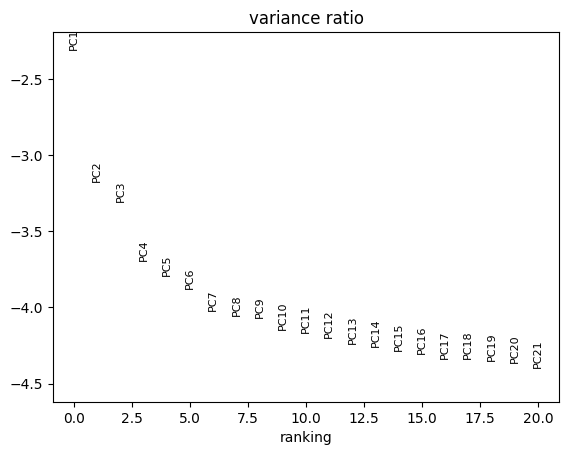

In [57]:
#### log = True. Use only this if the first few pcs have a larger gap in between
import numpy as np
sc.pl.pca_variance_ratio(adata, n_pcs=20, log=True)
pca_variance_ratio = adata.uns['pca']['variance_ratio']

### for plotting using plotty we have to use np.log() to apply lograthmic scale to it.
variance_ratio_log = np.log(pca_variance_ratio)


In [ ]:
fig = px.line(
    x=range(1, len(pca_variance_ratio[:20]) + 1),
    y=pca_variance_ratio[:20],
    labels={'x': 'Principal Components', 'y': 'Variance Explained'},
    title="Elbow Plot"
)

# Optionally, add markers at the points for better visualization
fig.update_traces(mode="lines+markers")
fig.show()

In [ ]:
### Heatmap ##########

top_genes_per_pc = 200
pcs_to_plot = range(1, 11)  # PCs 1 to 20

# Get the loadings of each gene on the PCs
loadings = adata.varm['PCs']

# Get the top contributing genes for each PC
top_genes = {}
for pc in pcs_to_plot:
    # Get absolute values of loadings for the current PC
    pc_loadings = np.abs(loadings[:, pc-1])
    
    # Sort genes by their loading values, and select top genes
    top_gene_indices = np.argsort(pc_loadings)[-top_genes_per_pc:]
    top_genes[pc] = adata.var_names[top_gene_indices].tolist()

In [ ]:
cells_to_plot = list(adata.obs_names)[:50]
adata_subset = adata[cells_to_plot, :]

gene_expression_matrix = []
gene_labels = []

for pc, genes in top_genes.items():
    gene_expression = adata_subset[:, genes].X.toarray()  # Extract gene expression data
    gene_expression_matrix.append(gene_expression)
    gene_labels.extend(genes)

# Combine data for all PCs into a single matrix
gene_expression_matrix = np.concatenate(gene_expression_matrix, axis=1)

In [ ]:
fig = make_subplots(
    rows=5, cols=4, 
    subplot_titles=[f'PC {pc}' for pc in pcs_to_plot],
    vertical_spacing=0.1, horizontal_spacing=0.1
)

# Loop through each PC and plot the top genes in a subplot
row = 1
col = 1
for pc in pcs_to_plot:
    genes = top_genes[pc]
    gene_expression = adata_subset[:, genes].X.toarray()  # Extract gene expression data

    # Add the heatmap for this PC to the subplot
    fig.add_trace(
        go.Heatmap(
            z=gene_expression.T,  # Transpose for correct orientation
            x=cells_to_plot,
            y=genes,
            colorscale='Viridis',
            showscale=False,  # Disable individual colorbars
        ),
        row=row, col=col
    )

    # Update subplot position
    col += 1
    if col > 4:  # Move to the next row after 4 columns
        col = 1
        row += 1

# Update layout
fig.update_layout(
    title='PC Heatmaps (Top 20 Genes per PC)',
    height=1000, width=1200,
    showlegend=False
)

fig.show()

# # Loop through each PC and plot the heatmap individually
# for pc in pcs_to_plot:
#     genes = top_genes[pc]  # Get the top genes for this PC
#     gene_expression = adata_subset[:, genes].X.toarray()  # Extract gene expression data
    
#     # Create a new figure for each PC
#     fig = go.Figure(
#         data=go.Heatmap(
#             z=gene_expression.T,  # Transpose for correct orientation
#             x=cells_to_plot,
#             y=genes,
#             colorscale='Viridis',
#             showscale=True  # Enable the colorbar for individual heatmaps
#         )
#     )
    
#     # Update layout for each plot
#     fig.update_layout(
#         title=f'PC {pc} Heatmap (Top 20 Genes)',
#         height=500, width=600,  # Adjust the size as per your preference
#         showlegend=False
#     )
    
#     # Display the figure
#     fig.show()


In [58]:
adata

AnnData object with n_obs × n_vars = 102 × 17613
    obs: 'label', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'log1p_norm'

In [62]:
adata.obs['batch'] = adata.obs['label']
# adata.obs['batch1'] = adata.obs['replicate']
# adata.obs['batch2'] = adata.obs['replicate'].astype(str) + '_' + adata.obs['label'].astype(str)

Batch Correction

In [63]:

sc.external.pp.harmony_integrate(adata,key = 'batch')

2024-12-03 01:10:29,085 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2024-12-03 01:10:29,139 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-12-03 01:10:29,141 - harmonypy - INFO - Iteration 1 of 10
2024-12-03 01:10:29,181 - harmonypy - INFO - Iteration 2 of 10
2024-12-03 01:10:29,219 - harmonypy - INFO - Iteration 3 of 10
2024-12-03 01:10:29,247 - harmonypy - INFO - Iteration 4 of 10
2024-12-03 01:10:29,264 - harmonypy - INFO - Iteration 5 of 10
2024-12-03 01:10:29,288 - harmonypy - INFO - Converged after 5 iterations


In [64]:
adata

AnnData object with n_obs × n_vars = 102 × 17613
    obs: 'label', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0.25', 'batch'
    var: 'gene', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'leiden_res0.25', 'leiden_res0.25_colors', 'label_colors'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'log1p_norm'
    obsp: 'distances', 'connectivities'

In [ ]:
### tsne ####
# adata.obsm['X_pca_6'] = adata.obsm['X_pca'][:, :6]
sc.tl.tsne(adata, use_rep="X_pca")

In [ ]:
sc.pl.tsne(adata, color="total_counts")

In [ ]:
adata

In [ ]:
# sc.pp.neighbors(adata, n_pcs=7, n_neighbors=15, use_rep='X_pca')
# sc.tl.umap(adata, min_dist=0.1, spread=1.0, random_state=42)


### UMAP ###
sc.pp.neighbors(adata,n_pcs=6)
sc.tl.umap(adata)

In [ ]:
adata.obs

In [ ]:
sc.pl.umap(adata, color="total_counts")

In [ ]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "scDblFinder_score", "scDblFinder_class"],
)

In [ ]:
adata

Clustering

In [59]:
sc.pp.neighbors(adata, n_pcs=7, n_neighbors=15, use_rep='X_pca')
sc.tl.umap(adata, min_dist=0.1, spread=1.0, random_state=42)

In [60]:
sc.tl.leiden(adata, key_added="leiden_res0.25", resolution=0.25)
# sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
# sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

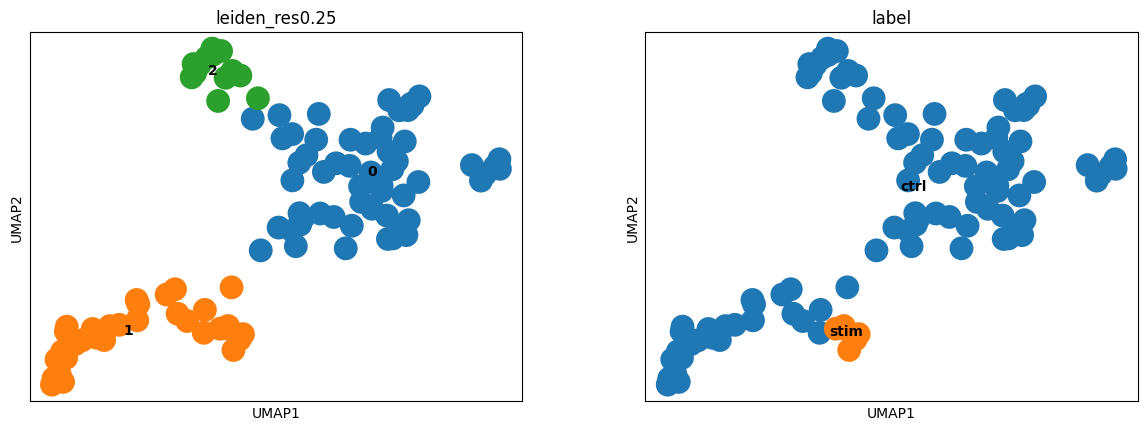

In [61]:
sc.pl.umap(
    adata,
    color=["leiden_res0.25", "label"],
    legend_loc="on data",
)

In [9]:
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0.25', 'batch', 'batch1', 'batch2'
    var: 'name', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res0.25', 'neighbors', 'pca', 'rank_genes_groups', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'log1p_norm'
    obsp: 'connectivities', 'distances'

with Batch correction (lablel column only)

In [65]:
sc.pp.neighbors(adata, n_pcs=7, n_neighbors=15, use_rep='X_pca_harmony')
sc.tl.umap(adata, min_dist=0.1, spread=1.0, random_state=42)

In [66]:
sc.tl.leiden(adata, key_added="leiden_res0.25", resolution=0.25)

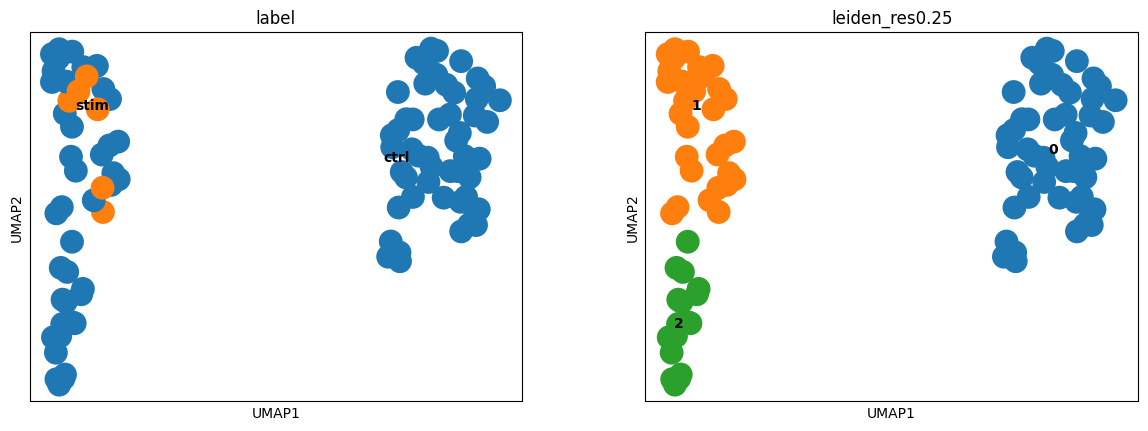

In [67]:
sc.pl.umap(
    adata,
    color=["label","leiden_res0.25"],
    legend_loc="on data",
)

with Batch correction (patients)

In [37]:
sc.pp.neighbors(adata, n_pcs=7, n_neighbors=15, use_rep='X_pca_harmony')
sc.tl.umap(adata, min_dist=0.1, spread=1.0, random_state=42)

In [38]:
sc.tl.leiden(adata, key_added="leiden_res0.25", resolution=0.25)

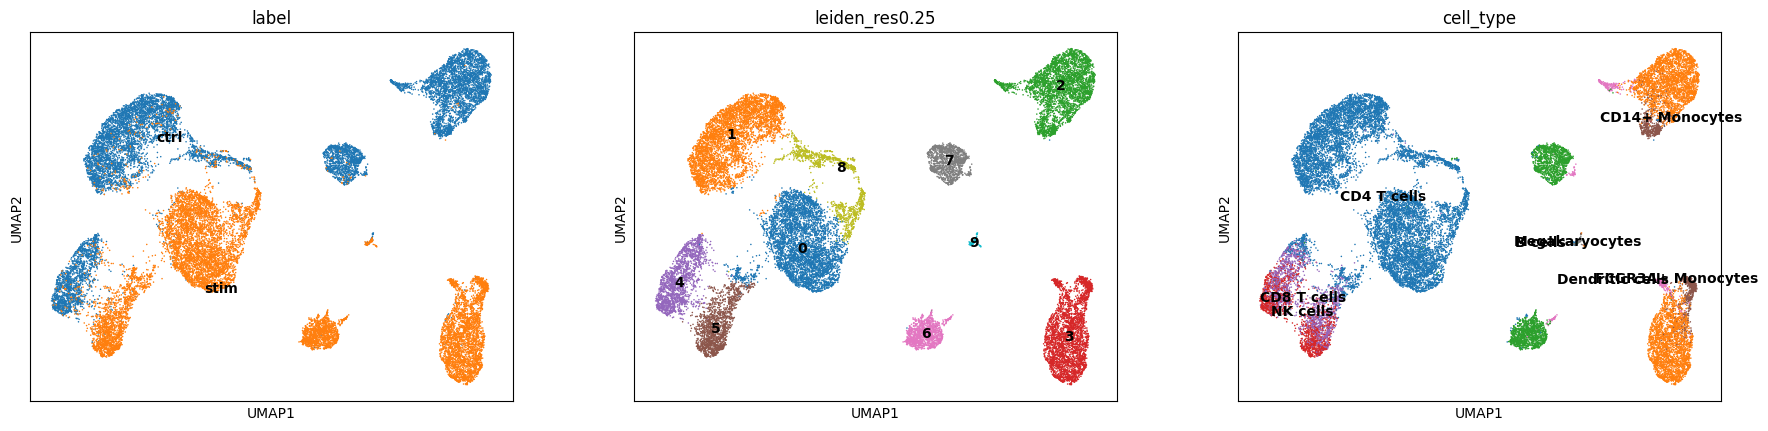

In [40]:
sc.pl.umap(
    adata,
    color=["label","leiden_res0.25","cell_type"],
    legend_loc="on data",
)

With batch Correction (label + replicate)

In [18]:
sc.pp.neighbors(adata, n_pcs=7, n_neighbors=15, use_rep='X_pca_harmony')
sc.tl.umap(adata, min_dist=0.1, spread=1.0, random_state=42)

In [19]:
sc.tl.leiden(adata, key_added="leiden_res0.25", resolution=0.25)

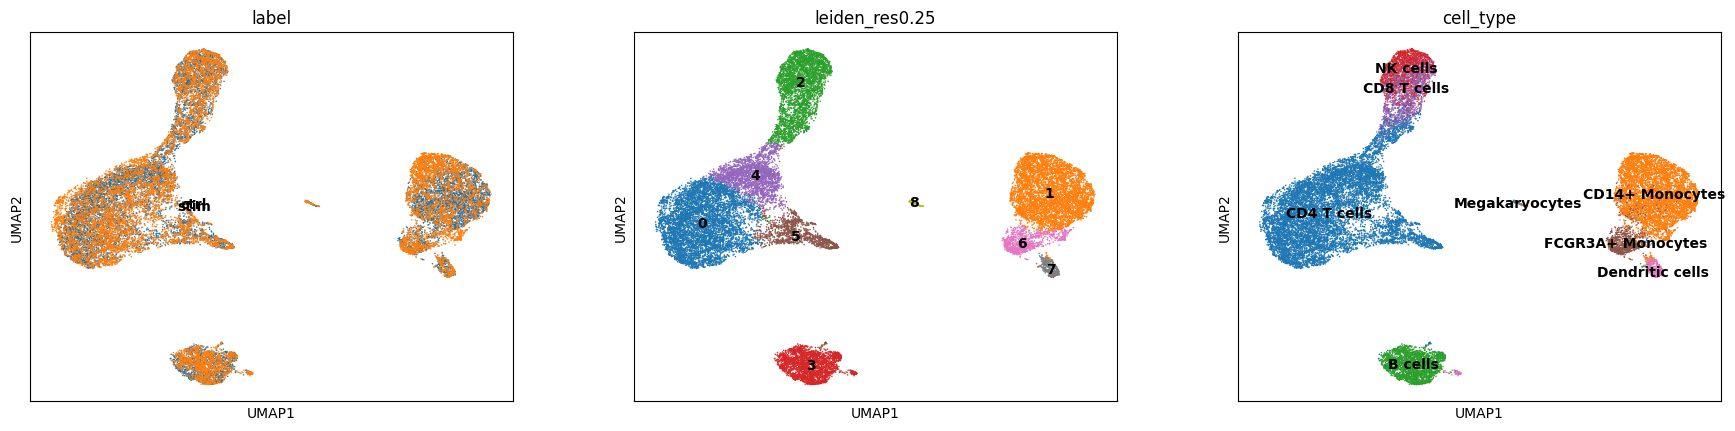

In [20]:
sc.pl.umap(
    adata,
    color=["label","leiden_res0.25","cell_type"],
    legend_loc="on data",
)

In [68]:
adata.write("D:/Raylab/LiMeNEx/NewCountMatrixData/Data1/adata.h5ad")

without Batch correction

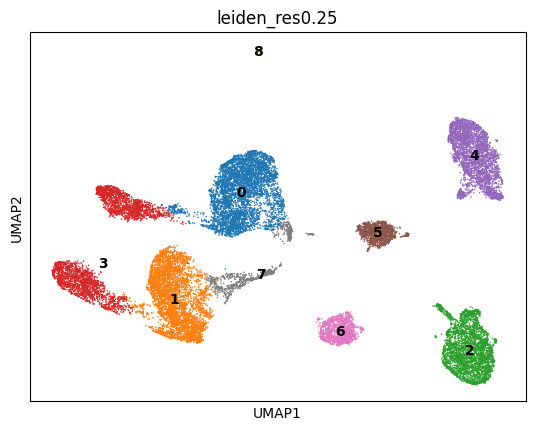

In [15]:
sc.pl.umap(
    adata,
    color=["leiden_res0.25"],
    legend_loc="on data",
)

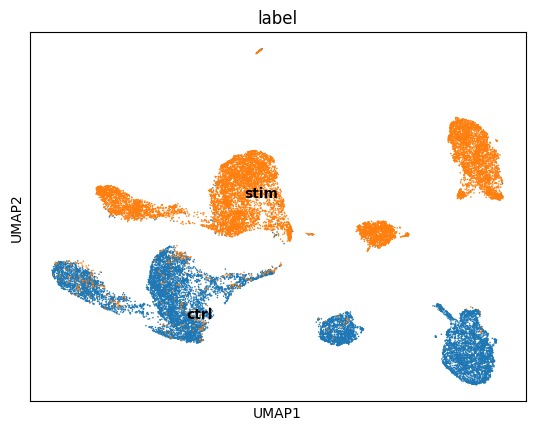

In [16]:
sc.pl.umap(
    adata,
    color=["label"],
    legend_loc="on data",
)

In [84]:
adata

AnnData object with n_obs × n_vars = 102 × 17613
    obs: 'label', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0.25', 'batch'
    var: 'gene', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'leiden_res0.25', 'leiden_res0.25_colors', 'label_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'log1p_norm'
    obsp: 'distances', 'connectivities'

In [70]:
# Run differential expression to identify marker genes for each Leiden cluster
sc.tl.rank_genes_groups(adata, groupby='label', method='wilcoxon',layer='log1p_norm')

# # View the results
# sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [76]:
adata.uns['rank_genes_groups']['names'].dtype.names

('ctrl', 'stim')

In [ ]:
# adata.X = adata.layers['log1p_norm']

In [ ]:
adata.uns['rank_genes_groups']

In [ ]:
len(adata.uns['rank_genes_groups']['logfoldchanges'])

In [77]:
group_names = adata.uns['rank_genes_groups']['names'].dtype.names
n = len(adata.uns['rank_genes_groups']['names'])
cluster_gene_dataframes = []

for group in group_names:
    # Collect rows as dictionaries and convert them to a DataFrame at the end
    rows = [
        {
            "Gene": adata.uns['rank_genes_groups']['names'][group][i],
            "Score": adata.uns['rank_genes_groups']['scores'][group][i],
            "LogFoldChange": adata.uns['rank_genes_groups']['logfoldchanges'][group][i],
            "AdjustedPValue": adata.uns['rank_genes_groups']['pvals_adj'][group][i]
        }
        for i in range(n)
    ]
    # Create DataFrame from list of dictionaries
    df = pd.DataFrame(rows, columns=['Gene', 'Score', 'LogFoldChange', 'AdjustedPValue'])
    cluster_gene_dataframes.append(df)


In [83]:
cluster_gene_dataframes[0].to_csv("D:/Raylab/LiMeNEx/NewCountMatrixData/Data1/ctrl.csv",index = False)

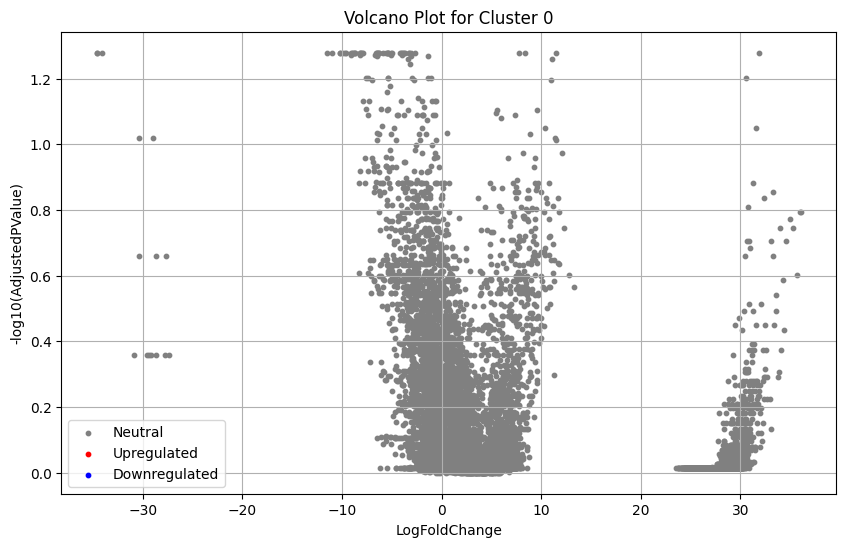

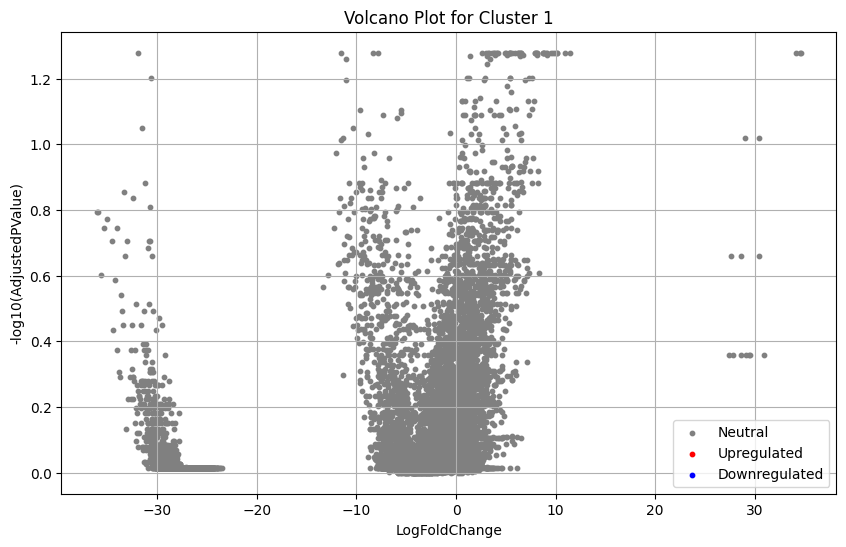

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# Define threshold for significant genes (adjust based on your requirements)
logfc_threshold = 1  # Example threshold for LogFoldChange
pval_threshold = 0.05  # Example threshold for AdjustedPValue

# Loop through each cluster to generate a volcano plot
for i, df in enumerate(cluster_gene_dataframes):
    plt.figure(figsize=(10, 6))
    
    # Calculate -log10(AdjustedPValue) for plotting
    df['-log10(p-adjusted)'] = -np.log10(df['AdjustedPValue'])
    
    # Define upregulated, downregulated, and neutral genes based on thresholds
    upregulated = (df['LogFoldChange'] > logfc_threshold) & (df['AdjustedPValue'] < pval_threshold)
    downregulated = (df['LogFoldChange'] < -logfc_threshold) & (df['AdjustedPValue'] < pval_threshold)
    neutral = ~(upregulated | downregulated)
    
    # Scatter plot for each category
    plt.scatter(df[neutral]['LogFoldChange'], df[neutral]['-log10(p-adjusted)'], color='gray', label='Neutral', s=10)
    plt.scatter(df[upregulated]['LogFoldChange'], df[upregulated]['-log10(p-adjusted)'], color='red', label='Upregulated', s=10)
    plt.scatter(df[downregulated]['LogFoldChange'], df[downregulated]['-log10(p-adjusted)'], color='blue', label='Downregulated', s=10)
    
    # Label the plot
    plt.xlabel('LogFoldChange')
    plt.ylabel('-log10(AdjustedPValue)')
    plt.title(f'Volcano Plot for Cluster {i}')
    plt.legend()
    plt.grid(True)
    plt.show()


Dot PLot

In [ ]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden_2", standard_scale="var", n_genes=5, key="dea_leiden_2"
)

Volcano Plot

In [ ]:
import plotly.express as px
import numpy as np
import pandas as pd

# Define threshold for significant genes (adjust based on your requirements)
logfc_threshold = 1  # Example threshold for LogFoldChange
pval_threshold = 0.05  # Example threshold for AdjustedPValue

# Loop through each cluster to generate a volcano plot
for i, df in enumerate(cluster_gene_dataframes):
    # Calculate -log10(AdjustedPValue) for plotting
    df['-log10(p-adjusted)'] = -np.log10(df['AdjustedPValue'])

    # Define upregulated, downregulated, and neutral genes based on thresholds
    df['Category'] = 'Neutral'  # Default category
    df.loc[(df['LogFoldChange'] > logfc_threshold) & (df['AdjustedPValue'] < pval_threshold), 'Category'] = 'Upregulated'
    df.loc[(df['LogFoldChange'] < -logfc_threshold) & (df['AdjustedPValue'] < pval_threshold), 'Category'] = 'Downregulated'

    # Create the volcano plot
    fig = px.scatter(df, x='LogFoldChange', y='-log10(p-adjusted)', color='Category',
                     color_discrete_map={'Neutral': 'gray', 'Upregulated': 'red', 'Downregulated': 'blue'},
                     title=f'Volcano Plot for Cluster {i}',
                     labels={'LogFoldChange': 'Log Fold Change', '-log10(p-adjusted)': '-log10(Adjusted P-Value)'},
                     template='plotly_white')

    # Update layout to show grid
    fig.update_layout(showlegend=True)
    fig.show()


Differetial Gene Expression between conditions

In [ ]:
adata.X = adata.layers['log1p_norm']

In [ ]:
def prep_anndata(adata_):
    def fix_dtypes(adata_):
        # df = pd.DataFrame(adata_.X.A, index=adata_.obs_names, columns=adata_.var_names)
        df = pd.DataFrame(adata_.X.toarray(), index=adata_.obs_names, columns=adata_.var_names)

        df = df.join(adata_.obs)
        return sc.AnnData(df[adata_.var_names], obs=df.drop(columns=adata_.var_names))

    adata_ = fix_dtypes(adata_)
    sc.pp.filter_genes(adata_, min_cells=3)
    return adata_


In [ ]:
adata

In [ ]:
adata_mono = adata[adata.obs["cell_type"] == "CD14+ Monocytes"].copy()
adata_mono

In [ ]:
sc.pp.filter_genes(adata, min_cells=3)
adata

In [ ]:
adata = prep_anndata(adata)
adata

In [ ]:
adata.obs["cell_type"] = [
    ct.replace(" ", "_") for ct in adata.obs["cell_type"]
]
adata.obs["cell_type"] = [
    ct.replace("+", "") for ct in adata.obs["cell_type"]
]

In [ ]:
%%R
find_de_MAST_RE <- function(adata_){
    # create a MAST object
    sca <- SceToSingleCellAssay(adata_, class = "SingleCellAssay")
    print("Dimensions before subsetting:")
    print(dim(sca))
    print("")
    # keep genes that are expressed in more than 10% of all cells
    sca <- sca[freq(sca)>0.1,]
    print("Dimensions after subsetting:")
    print(dim(sca))
    print("")
    # add a column to the data which contains scaled number of genes that are expressed in each cell
    cdr2 <- colSums(assay(sca)>0)
    colData(sca)$ngeneson <- scale(cdr2)
    # store the columns that we are interested in as factors
    label <- factor(colData(sca)$label)
    # set the reference level
    label <- relevel(label,"ctrl")
    colData(sca)$label <- label
    celltype <- factor(colData(sca)$cell_type)
    colData(sca)$celltype <- celltype
    # same for donors (which we need to model random effects)
    replicate <- factor(colData(sca)$replicate)
    colData(sca)$replicate <- replicate
    # create a group per condition-celltype combination
    colData(sca)$group <- paste0(colData(adata_)$label, ".", colData(adata_)$cell_type)
    colData(sca)$group <- factor(colData(sca)$group)
    # define and fit the model
    zlmCond <- zlm(formula = ~ngeneson + group + (1 | replicate), 
                   sca=sca, 
                   method='glmer', 
                   ebayes=F, 
                   strictConvergence=F,
                   fitArgsD=list(nAGQ = 0)) # to speed up calculations
    
    # perform likelihood-ratio test for the condition that we are interested in    
    summaryCond <- summary(zlmCond, doLRT='groupstim.CD14_Monocytes')
    # get the table with log-fold changes and p-values
    summaryDt <- summaryCond$datatable
    result <- merge(summaryDt[contrast=='groupstim.CD14_Monocytes' & component=='H',.(primerid, `Pr(>Chisq)`)], # p-values
                     summaryDt[contrast=='groupstim.CD14_Monocytes' & component=='logFC', .(primerid, coef)],
                     by='primerid') # logFC coefficients
    # MAST uses natural logarithm so we convert the coefficients to log2 base to be comparable to edgeR
    result[,coef:=result[,coef]/log(2)]
    # do multiple testing correction
    result[,FDR:=p.adjust(`Pr(>Chisq)`, 'fdr')]
    result = result[result$FDR<0.01,, drop=F]

    result <- stats::na.omit(as.data.frame(result))
    return(result)
}

In [ ]:
%%R
find_de_MAST_RE_mod <- function(adata_,celltype){
    # create a MAST object
    sca <- SceToSingleCellAssay(adata_[, colData(adata_)$cell_type == cell_type], class = "SingleCellAssay")
    print("Dimensions before subsetting:")
    print(dim(sca))
    print("")
    # keep genes that are expressed in more than 10% of all cells
    sca <- sca[freq(sca)>0.1,]
    print("Dimensions after subsetting:")
    print(dim(sca))
    print("")
    # add a column to the data which contains scaled number of genes that are expressed in each cell
    cdr2 <- colSums(assay(sca)>0)
    colData(sca)$ngeneson <- scale(cdr2)
    # store the columns that we are interested in as factors
    label <- factor(colData(sca)$label)
    # set the reference level
    label <- relevel(label,"ctrl")
    colData(sca)$label <- label
    celltype <- factor(colData(sca)$cell_type)
    colData(sca)$celltype <- celltype
    # same for donors (which we need to model random effects)
    replicate <- factor(colData(sca)$replicate)
    colData(sca)$replicate <- replicate
    # create a group per condition-celltype combination
    colData(sca)$group <- paste0(colData(adata_)$label, ".", colData(adata_)$cell_type)
    colData(sca)$group <- factor(colData(sca)$group)
    # define and fit the model
    zlmCond <- zlm(formula = ~ngeneson + group + (1 | replicate), 
                   sca=sca, 
                   method='glmer', 
                   ebayes=F, 
                   strictConvergence=F,
                   fitArgsD=list(nAGQ = 0)) # to speed up calculations
    
    # perform likelihood-ratio test for the condition that we are interested in    
    summaryCond <- summary(zlmCond, doLRT=paste0('groupstim.', cell_type))
    # get the table with log-fold changes and p-values
    summaryDt <- summaryCond$datatable
    result <- merge(summaryDt[contrast==paste0('groupstim.', cell_type) & component=='H',.(primerid, `Pr(>Chisq)`)], # p-values
                     summaryDt[contrast==paste0('groupstim.', cell_type) & component=='logFC', .(primerid, coef)],
                     by='primerid') # logFC coefficients
    # MAST uses natural logarithm so we convert the coefficients to log2 base to be comparable to edgeR
    result[,coef:=result[,coef]/log(2)]
    # do multiple testing correction
    result[,FDR:=p.adjust(`Pr(>Chisq)`, 'fdr')]
    result = result[result$FDR<0.01,, drop=F]

    result <- stats::na.omit(as.data.frame(result))
    return(result)
}

In [ ]:
import anndata as ad
import sc_toolbox

# List of cell types
cell_types = adata.obs['cell_type'].unique()

# Loop over each cell type, run MAST in R, and store results in AnnData
for cell_type in cell_types:
    print(f"Running MAST for cell type: {cell_type}")

    adata_mono = adata[adata.obs["cell_type"] == cell_type].copy()
    
    # Pass data and cell type to R and run the function explicitly
    %R -i adata_mono -i cell_type
    %R res <- find_de_MAST_RE_mod(adata_mono, cell_type)
    
    # Retrieve 'res' as output from R environment and store it in Python
    res = %R res

    res["gene_symbol"] = res["primerid"]
    res["cell_type"] = cell_type

    filename = f"/storage4tb-1/Aish/deResults/{cell_type}.csv"
    res.to_csv(filename, index=False)
    print(f"Saved results for {cell_type} to {filename}")
    
    # Add results to AnnData using the specific cell type key
    key_added = f"MAST_{cell_type}"
    sc_toolbox.tools.de_res_to_anndata(
        adata,
        res,
        groupby="cell_type",
        score_col="coef",
        pval_col="Pr(>Chisq)",
        pval_adj_col="FDR",
        lfc_col="coef",
        key_added=key_added,
    )

In [ ]:
adata.obs['cell_type'].unique()

In [ ]:
%%time
%%R -i adata_mono -o res
res <-find_de_MAST_RE(adata_mono)

In [ ]:
res

In [ ]:
res["gene_symbol"] = res["primerid"]
res["cell_type"] = "CD14_Monocytes"
sc_toolbox.tools.de_res_to_anndata(
    adata,
    res,
    groupby="cell_type",
    score_col="coef",
    pval_col="Pr(>Chisq)",
    pval_adj_col="FDR",
    lfc_col="coef",
    key_added="MAST_CD14_Monocytes",
)

In [ ]:
adata.uns

In [ ]:
FDR = 0.01
LOG_FOLD_CHANGE = 0.2


def plot_heatmap(adata, group_key, group_name="cell_type", groupby="label"):
    cell_type = "_".join(group_key.split("_")[1:])
    res = sc.get.rank_genes_groups_df(adata, group=cell_type, key=group_key)
    res.index = res["names"].values
    res = res[
        (res["pvals_adj"] < FDR) & (abs(res["logfoldchanges"]) > LOG_FOLD_CHANGE)
    ].sort_values(by=["logfoldchanges"])
    print(f"Plotting {len(res)} genes...")
    markers = list(res.index)
    sc.pl.heatmap(
        adata[adata.obs[group_name] == cell_type].copy(),
        markers,
        groupby=groupby,
        swap_axes=True,
    )

In [ ]:
plot_heatmap(adata, "MAST_CD14_Monocytes")

In [ ]:
FDR = 0.01
LOG_FOLD_CHANGE = 0.2


def volcano_plot(adata, group_key, group_name="cell_type", groupby="label", title=None):
    cell_type = "_".join(group_key.split("_")[1:])
    result = sc.get.rank_genes_groups_df(adata, group=cell_type, key=group_key).copy()
    result["-logQ"] = -np.log(result["pvals"].astype("float"))
    lowqval_de = result.loc[abs(result["logfoldchanges"]) > LOG_FOLD_CHANGE]
    other_de = result.loc[abs(result["logfoldchanges"]) <= LOG_FOLD_CHANGE]

    fig, ax = plt.subplots()
    sns.regplot(
        x=other_de["logfoldchanges"],
        y=other_de["-logQ"],
        fit_reg=False,
        scatter_kws={"s": 6},
    )
    sns.regplot(
        x=lowqval_de["logfoldchanges"],
        y=lowqval_de["-logQ"],
        fit_reg=False,
        scatter_kws={"s": 6},
    )
    ax.set_xlabel("log2 FC")
    ax.set_ylabel("-log Q-value")

    if title is None:
        title = group_key.replace("_", " ")
    plt.title(title)
    plt.show()

In [ ]:
volcano_plot(adata, "MAST_CD14_Monocytes")